In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(
    "../data/raw/ksp_synthetic_crime_dataset.csv"
)

df.head()

,crime_id,district,police_station,crime_type,date,latitude,longitude,victim_age,offender_age,status,repeat_offender
0,CR000001,Kalaburagi,Kalaburagi PS 4,Vehicle Theft,2023-09-28,17.362084,76.910451,56,36,Closed,0
1,CR000002,Ballari,Ballari PS 5,Assault,2025-05-21,15.110356,76.895142,38,50,Charge Sheet Filed,0
2,CR000003,Tumakuru,Tumakuru PS 1,Cybercrime,2023-02-28,13.314309,77.095126,33,32,Under Investigation,0
3,CR000004,Belagavi,Belagavi PS 4,Robbery,2023-09-01,15.822481,74.503246,68,24,Open,0
4,CR000005,Mysuru,Mysuru PS 4,Theft,2023-11-12,12.194464,76.695371,43,19,Charge Sheet Filed,0


In [3]:
df["date"] = pd.to_datetime(
    df["date"]
)

In [4]:
df["month"] = df["date"].dt.month

df["month_name"] = df["date"].dt.month_name()

df["weekday"] = df["date"].dt.day_name()

In [5]:
df[
[
    "date",
    "month",
    "month_name",
    "weekday"
]
].head()

,date,month,month_name,weekday
0,2023-09-28,9,September,Thursday
1,2025-05-21,5,May,Wednesday
2,2023-02-28,2,February,Tuesday
3,2023-09-01,9,September,Friday
4,2023-11-12,11,November,Sunday


In [6]:
monthly_crimes = (
    df.groupby("month_name")
    .size()
    .reset_index(name="crime_count")
)

monthly_crimes

,month_name,crime_count
0,April,1013
1,August,725
2,December,655
3,February,944
4,January,1007
5,July,728
6,June,890
7,March,1030
8,May,1040
9,November,636


In [7]:
month_order = [
    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December"
]

monthly_crimes["month_name"] = pd.Categorical(
    monthly_crimes["month_name"],
    categories=month_order,
    ordered=True
)

monthly_crimes = monthly_crimes.sort_values(
    "month_name"
)

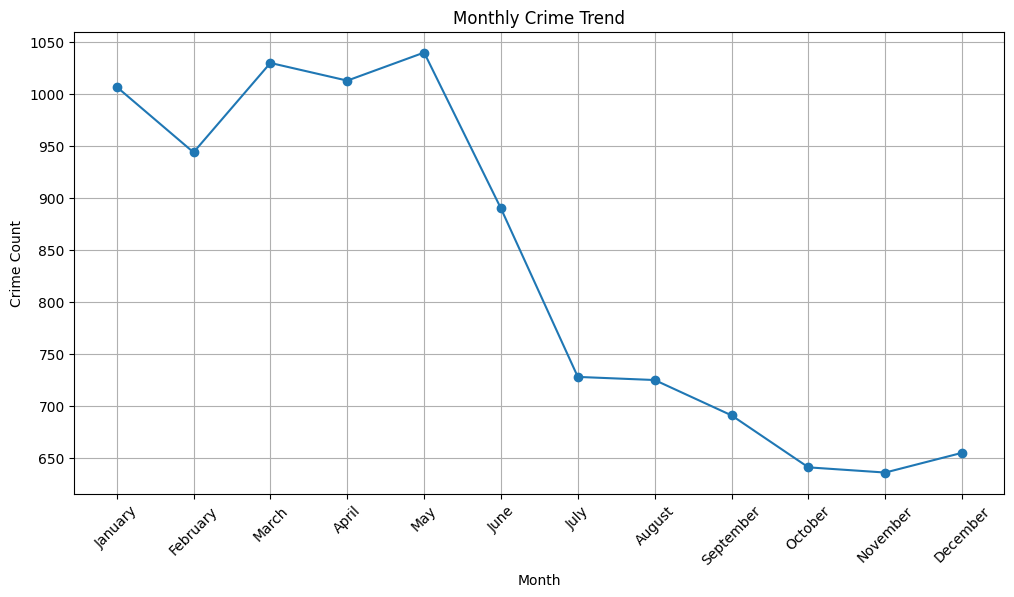

In [8]:
plt.figure(figsize=(12,6))

plt.plot(
    monthly_crimes["month_name"],
    monthly_crimes["crime_count"],
    marker="o"
)

plt.xticks(rotation=45)

plt.title(
    "Monthly Crime Trend"
)

plt.ylabel("Crime Count")

plt.xlabel("Month")

plt.grid(True)

plt.show()

In [9]:
monthly_crimes.to_csv(
    "../data/processed/monthly_crime_trends.csv",
    index=False
)

In [10]:
weekday_crimes = (
    df.groupby("weekday")
    .size()
    .reset_index(name="crime_count")
)

weekday_crimes

,weekday,crime_count
0,Friday,1410
1,Monday,1452
2,Saturday,1511
3,Sunday,1372
4,Thursday,1436
5,Tuesday,1391
6,Wednesday,1428


In [11]:
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_crimes["weekday"] = pd.Categorical(
    weekday_crimes["weekday"],
    categories=weekday_order,
    ordered=True
)

weekday_crimes = weekday_crimes.sort_values(
    "weekday"
)

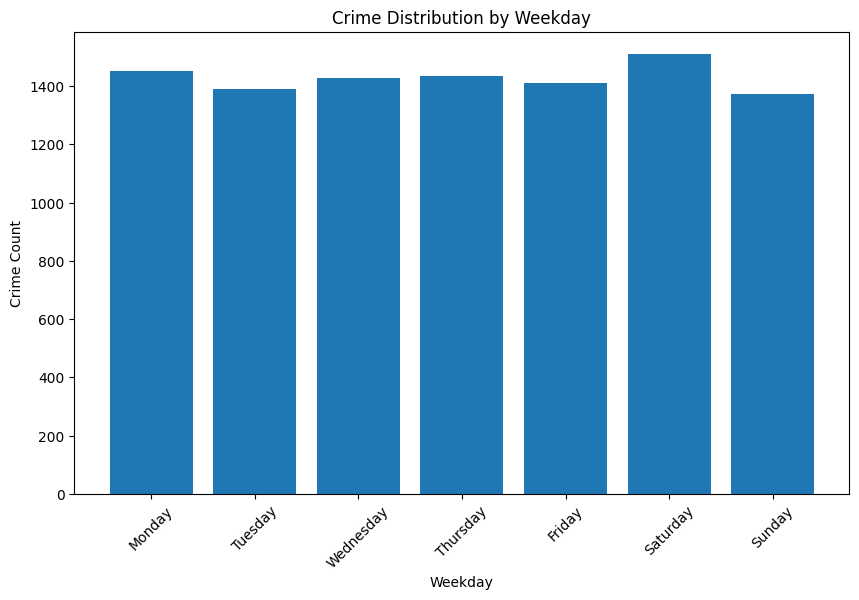

In [12]:
plt.figure(figsize=(10,6))

plt.bar(
    weekday_crimes["weekday"],
    weekday_crimes["crime_count"]
)

plt.title(
    "Crime Distribution by Weekday"
)

plt.ylabel("Crime Count")

plt.xlabel("Weekday")

plt.xticks(rotation=45)

plt.show()

In [13]:
weekday_crimes.to_csv(
    "../data/processed/weekday_crime_trends.csv",
    index=False
)

In [14]:
crime_types = (
    df["crime_type"]
    .value_counts()
    .reset_index()
)

crime_types.columns = [
    "crime_type",
    "count"
]

crime_types

,crime_type,count
0,Vehicle Theft,1340
1,Burglary,1282
2,Robbery,1270
3,Drug Offence,1257
4,Fraud,1238
5,Assault,1226
6,Cybercrime,1206
7,Theft,1181


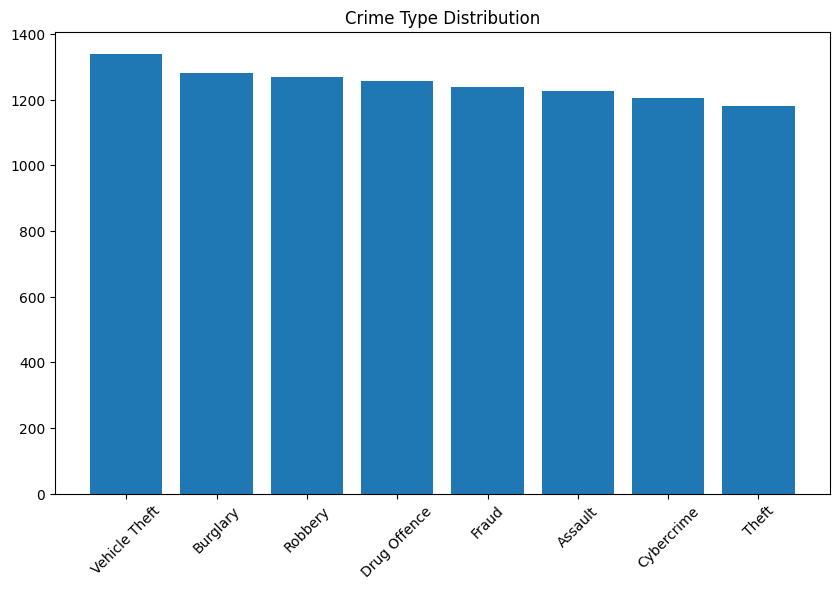

In [15]:
plt.figure(figsize=(10,6))

plt.bar(
    crime_types["crime_type"],
    crime_types["count"]
)

plt.title(
    "Crime Type Distribution"
)

plt.xticks(rotation=45)

plt.show()

# Temporal Crime Intelligence

## Key Findings

1. Monthly crime analysis identifies periods with increased criminal activity.

2. Weekday analysis helps optimize police patrol scheduling.

3. Crime type distribution highlights the most common offences.

4. Temporal intelligence supports proactive law enforcement planning.

5. Results can be used to allocate police resources more efficiently.